# 01 — Análisis Exploratorio y Clustering de Estudiantes (CRISP-DM: fases 1 y 2)

## Objetivos
- Formular el **problema** en términos de tarea de ML no supervisado (clustering).
- Explorar el **origen** de los datos (`tabla_maestra.csv`) y realizar preprocesamiento.
- Implementar y evaluar un modelo de **K-Means** usando métodos de optimización (Codo y Silhouette).
- Visualizar segmentos de estudiantes aplicando **PCA**.

## Justificación Técnica
El uso de aprendizaje no supervisado nos permitirá descubrir patrones subyacentes en el comportamiento académico de los estudiantes, agrupándolos según características como sus promedios y ausencias, sin depender de una etiqueta o clasificación previa.

In [1]:
%load_ext kedro.ipython

[05/12/26 18:42:05] INFO     Using                                                                  ]8;id=9075244;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/framework/project/__init__.py\__init__.py]8;;\:]8;id=9075245;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/framework/project/__init__.py#275\275]8;;\
                             '/Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/py                
                             thon3.13/site-packages/kedro/framework/project/rich_logging.yml' as                   
                             logging configuration.                                                                

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=9075252;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=9075253;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py#64\64]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=9075259;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=9075260;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py#66\66]8;;\

                    INFO     Resolved project path as:                                              ]8;id=9075266;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=9075267;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py#181\181]8;;\
                             /Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe.                             
                             To set a different path, run '%reload_kedro <project_root>'                           

[05/12/26 18:42:05] INFO     No typed parameter requirements found, returning original   ]8;id=9075274;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/validation/parameter_validator.py\parameter_validator.py]8;;\:]8;id=9075275;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/validation/parameter_validator.py#108\108]8;;\
                             parameters                                                                            

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=9075282;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro_telemetry/plugin.py\plugin.py]8;;\:]8;id=9075283;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro_telemetry/plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[05/12/26 18:42:06] INFO     Kedro project ev_parcial1_uribe                                        ]8;id=9075289;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=9075290;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py#147\147]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=9075296;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=9075297;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/kedro/ipython/__init__.py#148\148]8;;\
                             'pipelines'                                                                           

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").is_file() and (PROJECT_ROOT.parent / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "03_primary" / "tabla_maestra.csv"
assert (PROJECT_ROOT / "pyproject.toml").is_file(), (
    "Abre este notebook desde la raíz del proyecto con `kedro jupyter lab`."
)
assert DATA_PATH.is_file(), (
    f"No existe el archivo {DATA_PATH}. Verifica que el pipeline anterior se haya ejecutado correctamente."
)
print(f"Proyecto: {PROJECT_ROOT}")
print(f"Datos: {DATA_PATH}")

Proyecto: /Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe
Datos: /Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/data/03_primary/tabla_maestra.csv


## 1. Carga de Datos y Preprocesamiento

### Justificación Técnica
Cargaremos los datos consolidados y seleccionaremos las variables numéricas más relevantes para el rendimiento (ej. `promedio_notas`, `total_ausencias`). Se aplicará imputación básica para valores faltantes y un escalado estandarizado (`StandardScaler`) debido a que los algoritmos basados en cálculo de distancias (como K-Means y PCA) son altamente sensibles a la magnitud de las variables introducidas.

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Carga de datos
df = pd.read_csv(DATA_PATH)

# Seleccionar variables numéricas relevantes (ej. promedio_notas, total_ausencias)
# Se imputan valores nulos con la mediana para no perder filas críticas en el proceso de clustering
feat_cols = ["total_ausencias", "promedio_notas"]
df_numeric = df[feat_cols].fillna(df[feat_cols].median())

X = df_numeric
X_scaled = StandardScaler().fit_transform(X)

print("Dimensiones de los datos escalados:", X_scaled.shape)
df_numeric.head()

Dimensiones de los datos escalados: (1298, 2)


,total_ausencias,promedio_notas
0,0.0,1.9
1,0.0,4.4
2,1.0,2.7
3,0.0,4.4
4,0.0,6.7


## 2. Optimización No Supervisada: Selección del valor óptimo de k

### Justificación Técnica
Para determinar el número ideal de clusters (`k`), utilizaremos dos métricas complementarias:
- **Método del Codo (Elbow Method):** Evalúa la inercia (suma de distancias al cuadrado desde cada punto a su centroide). Buscamos el "punto de inflexión".
- **Silhouette Score:** Mide cuán similar es un objeto a su propio cluster en comparación con otros clusters vecinos. Valores más cercanos a 1 indican una mejor y más clara separación.

[05/12/26 18:42:38] WARNING  Matplotlib is building the font cache; this may take a moment.    ]8;id=9075304;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/matplotlib/font_manager.py\font_manager.py]8;;\:]8;id=9075305;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial1ds_uribe/.venv/lib/python3.13/site-packages/matplotlib/font_manager.py#1095\1095]8;;\

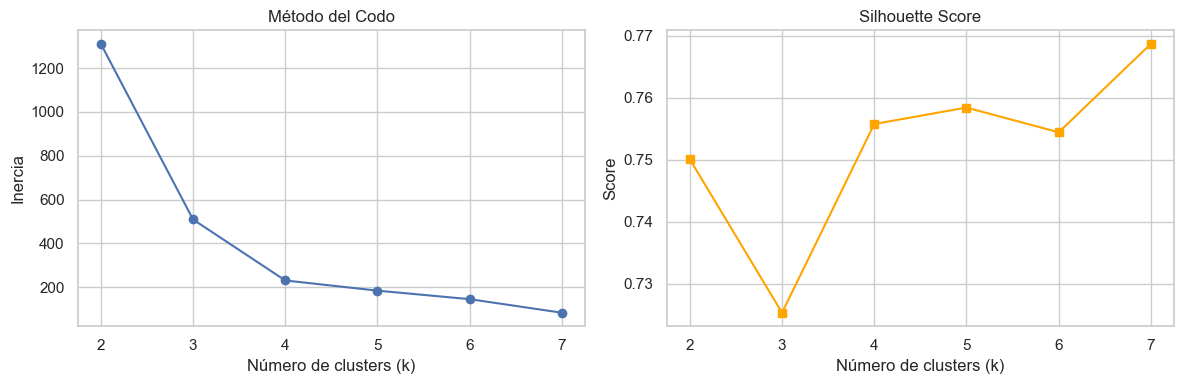

El número óptimo de clusters (k) empíricamente es: 7


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid", context="notebook")

inertias = []
silhouette_scores = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico del Codo
axes[0].plot(k_range, inertias, marker='o')
axes[0].set_title("Método del Codo")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia")

# Gráfico de Silhouette
axes[1].plot(k_range, silhouette_scores, marker='s', color='orange')
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

# Seleccionar el mejor k basado en el Silhouette Score máximo
best_k = k_range[np.argmax(silhouette_scores)]
print("El número óptimo de clusters (k) empíricamente es:", best_k)

## 3. Modelado: Implementación de K-Means

Entrenaremos el modelo definitivo de clustering con el `k` óptimo encontrado y asignaremos a cada estudiante su segmento correspondiente para su análisis descriptivo.

In [5]:
# Implementar K-Means con el k óptimo
km_final = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
df["cluster"] = km_final.fit_predict(X_scaled)

# Promedios por cluster para ayudar a la interpretación del negocio
resumen_clusters = df.groupby("cluster")[feat_cols].mean().round(2)
resumen_clusters["cantidad"] = df["cluster"].value_counts()
resumen_clusters

,total_ausencias,promedio_notas,cantidad
cluster,,,
0,0.00,4.39,726
1,1.00,2.57,21
2,0.00,2.84,146
3,0.00,5.51,149
4,1.01,5.65,76
5,0.00,6.61,81
6,0.00,1.55,99


## 4. Visualización Científica mediante PCA

### Justificación Técnica
Dado que nuestro dataset estudiantil posee múltiples características, el uso de **PCA (Análisis de Componentes Principales)** nos permite reducir la dimensionalidad de las variables a 2 componentes principales. Esto facilita proyectar los clusters resultantes en un plano cartesiano 2D, permitiendo evaluar de forma puramente visual qué tan limpios o solapados se encuentran los grupos descubiertos.

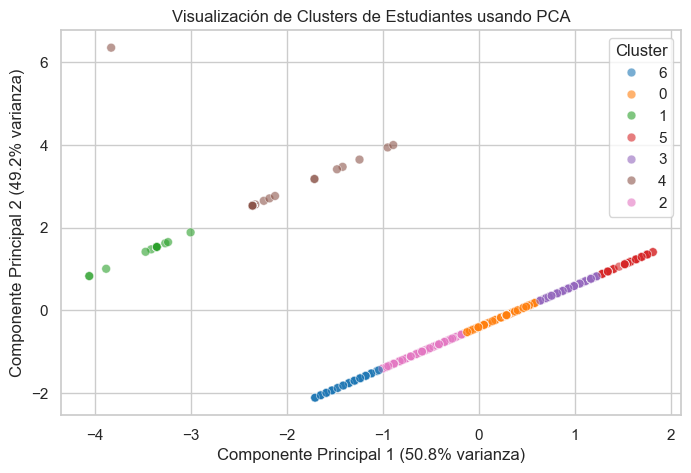

In [6]:
from sklearn.decomposition import PCA

pca_pipe = PCA(n_components=2, random_state=42)
components = pca_pipe.fit_transform(X_scaled)

pca_df = pd.DataFrame(components, columns=["PC1", "PC2"])
pca_df["cluster"] = df["cluster"].astype(str)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster", palette="tab10", alpha=0.6, s=40)
plt.title(f"Visualización de Clusters de Estudiantes usando PCA")
plt.xlabel(f"Componente Principal 1 ({pca_pipe.explained_variance_ratio_[0]:.1%} varianza)")
plt.ylabel(f"Componente Principal 2 ({pca_pipe.explained_variance_ratio_[1]:.1%} varianza)")
plt.legend(title="Cluster")
plt.show()

## 5. Análisis de Negocio y Conclusiones Técnicas

A partir de los centroides de K-Means y la distribución de los datos vista en el plano PCA, podemos identificar los siguientes perfiles estudiantiles fundamentales para nuestra tarea de negocio:

- **Perfil de Alto Rendimiento:** Estudiantes con calificaciones destacadas (promedios altos) y niveles nulos o muy bajos de ausencias. Son alumnos comprometidos.
- **Perfil Regular / Estable:** Estudiantes que mantienen una asistencia promedio y logran notas aceptables pero sin destacar mayormente. Conforman el segmento más grueso de la población estudiantil.
- **Perfil en Riesgo de Deserción:** Alumnos caracterizados por tener altas cantidades de ausencias combinadas frecuentemente con promedios deficientes. Este es el segmento crítico u "outcome" prioritario de análisis.

**Conclusión:**
La implementación de algoritmos de clustering no supervisado nos ha permitido segmentar la población académica empíricamente. Esta información estructural servirá para el diseño de estrategias preventivas tempranas por parte de la universidad, logrando detectar alumnos con dinámicas perjudiciales antes de que deriven en una deserción final.